In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:


# Define the folder containing the CSV files
folder_path = '../Code/Data/poc_pre-training/'

# Initialize an empty dictionary to store DataFrames
dfs = {}

# Loop through each file in the folder
for file in os.listdir(folder_path):
    if file.endswith('.csv'):  # Check if the file is a CSV
        file_path = os.path.join(folder_path, file)
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path)
        # Use the filename (without extension) as the dictionary key
        key = os.path.splitext(file)[0]
        dfs[key] = df

# Now `dfs` is a dictionary where keys are filenames and values are DataFrames


In [9]:
dfs['10000_1000000']

,Model A (Trained on target generator),Model B (Trained on alternative generators),"Model C (Pre-trained on alternative generators, fine-tuned on target generator)"
0,111.755557,124.918000,112.507901
1,115.455425,131.131644,118.999596
2,116.598155,125.802850,118.298354
3,117.815264,129.253983,117.765973
4,115.628066,126.833935,114.004810
5,116.327791,127.673133,120.994984
6,110.355517,117.955051,112.232396
7,109.437802,129.609482,114.522649
8,116.331187,123.993023,114.357181
9,107.337773,114.269449,106.587885


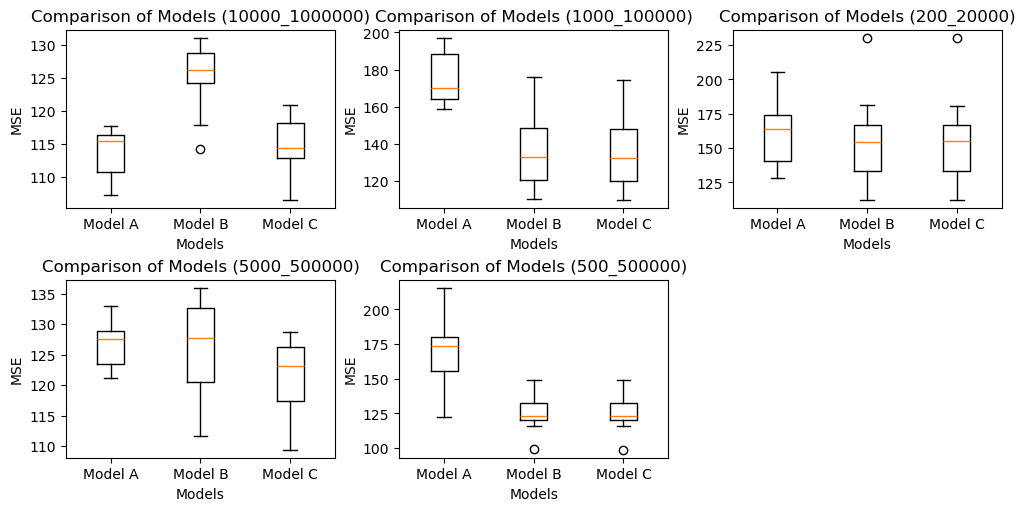

In [11]:
# Create a grid of subplots
n_plots = len(dfs)
n_cols = 3  # Number of columns in the grid
n_rows = -(-n_plots // n_cols)  # Ceiling division to determine rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5), constrained_layout=True)

# Flatten axes for easier indexing when grids have only one row
axes = axes.flatten()

# Loop over the DataFrames and plot each in its own subplot
for i, (key, df) in enumerate(dfs.items()):
    axes[i].boxplot([df['Model A (Trained on target generator)'], df['Model B (Trained on alternative generators)'], df['Model C (Pre-trained on alternative generators, fine-tuned on target generator)']])
    axes[i].set_xticks([1, 2, 3])
    axes[i].set_xticklabels(['Model A', 'Model B', 'Model C'])
    axes[i].set_xlabel('Models')
    axes[i].set_ylabel('MSE')
    axes[i].set_title(f'Comparison of Models ({key})')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Display the plots
plt.show()

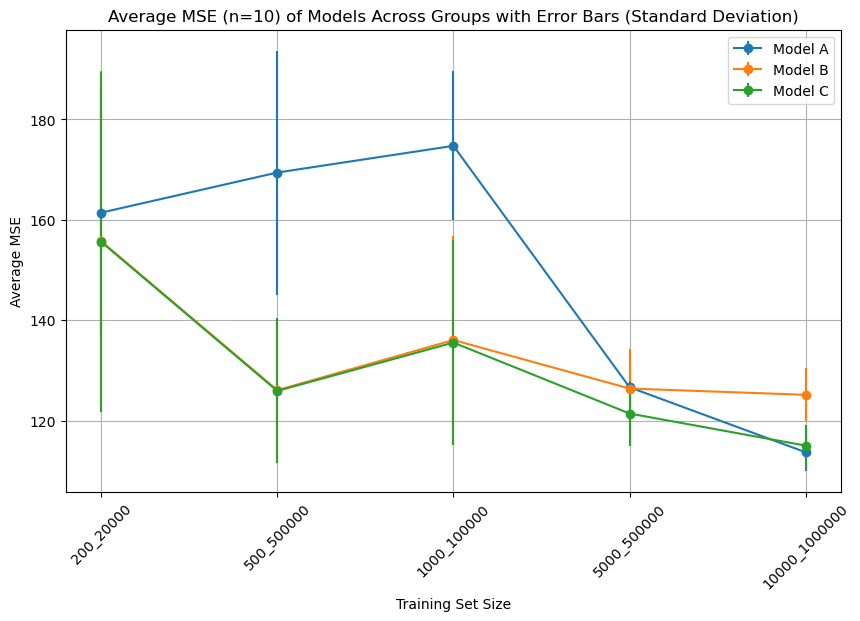

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine all DataFrames and add a 'group' column
combined_df = pd.concat(
    [df.assign(group=key) for key, df in dfs.items()], ignore_index=True
)

# Extract the numeric values from the group names for sorting
combined_df['numeric_group'] = combined_df['group'].apply(
    lambda x: int(x.split('_')[0])  # Use the first part of the group name for sorting
)

# Group by 'group' and calculate the mean and standard deviation for each group
grouped_stats = combined_df.groupby(['group', 'numeric_group']).agg(
    mean_model_a=('Model A (Trained on target generator)', 'mean'),
    std_model_a=('Model A (Trained on target generator)', 'std'),
    mean_model_b=('Model B (Trained on alternative generators)', 'mean'),
    std_model_b=('Model B (Trained on alternative generators)', 'std'),
    mean_model_c=('Model C (Pre-trained on alternative generators, fine-tuned on target generator)', 'mean'),
    std_model_c=('Model C (Pre-trained on alternative generators, fine-tuned on target generator)', 'std')
).reset_index()

# Sort by the numeric group values
grouped_stats.sort_values(by='numeric_group', inplace=True)

# Plotting with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(grouped_stats['group'], grouped_stats['mean_model_a'], 
             yerr=grouped_stats['std_model_a'], marker='o', label='Model A')
plt.errorbar(grouped_stats['group'], grouped_stats['mean_model_b'], 
             yerr=grouped_stats['std_model_b'], marker='o', label='Model B')
plt.errorbar(grouped_stats['group'], grouped_stats['mean_model_c'], 
             yerr=grouped_stats['std_model_c'], marker='o', label='Model C')

plt.xlabel('Training Set Size')
plt.ylabel('Average MSE')
plt.title('Average MSE (n=10) of Models Across Groups with Error Bars (Standard Deviation)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


Based on the graph above, we can see that Model B and C seem to outperform Model A in the middle range of training set sizes. Towards larger training set sizes Model catches up and outperforms Model B together with Model C.

It is also curious that Model A's MSE increases in the middle range before decreasing. This could be due to randomness. 

The data presented does not allow to conclude superiority of either of the three models for all training set sizes. There could be a sweet spot for training set size where pre-training on additional generators improves model performance due to the limited training set size, avoiding overfitting. With an increasing training set size derived from the target generator this benefit might diminish or even lead to a loss of specificty to the target generator, underfitting the model.

It also seems like fine-tuning always improves performance. Slightly, with smaller training set sizes and more strongly with larger ones. It might be the case that Model C offsets the overfitting trend for smaller training set sizes and as well as the underfitting trend for larger sizes.

In conclusion, Model C might be the best choice for a wider range of training set sizes due to its performance across training set sizes.